# AI detection model

## Library import

In [1]:
import pandas as pd
import spacy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import re

from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

from transformers import AutoTokenizer, AutoModelForSequenceClassification

from statsmodels.stats.contingency_tables import mcnemar

## Data import

0 - Human written paragraph 

1 - AI generated paragraph

In [2]:
df_human = pd.read_csv("victorian_texts_human.csv")
df_IA = pd.read_csv("IA_texts.csv", sep = ";")

In [3]:
# Renaming columns for consistency
df_human = df_human.rename(columns={"texte": "text", "titre": "title", "auteur": "author"})
df_IA = df_IA.rename(columns={"Text": "text"})

# Adding a label column to both dataframes
df_human["label"] = 0  # Human written
df_IA["label"] = 1     # AI generated

# Combining the dataframes
df = pd.concat([df_human, df_IA], ignore_index=True)
df

,text,title,author,label
0,“The twinkling of the _what?_” said the King. ...,Alice's Adventures in Wonderland,Lewis Carroll,0
1,The first thing she heard was a general chorus...,Alice's Adventures in Wonderland,Lewis Carroll,0
2,"“Nobody asked _your_ opinion,” said Alice. “Wh...",Alice's Adventures in Wonderland,Lewis Carroll,0
3,"The executioner’s argument was, that you could...",Alice's Adventures in Wonderland,Lewis Carroll,0
4,“I haven’t the least idea what you’re talking ...,Alice's Adventures in Wonderland,Lewis Carroll,0
...,...,...,...,...
995,"Heathcliff knelt in the mud, his hands pressed...",Wuthering Heights,MistralAI,1
996,Young Cathy Linton’s laughter rang through the...,Wuthering Heights,MistralAI,1
997,Hareton Earnshaw’s hands shook as he fastened ...,Wuthering Heights,MistralAI,1
998,"Nelly found Heathcliff in the old barn, his fa...",Wuthering Heights,MistralAI,1


## Embeddings

In [4]:
# Cleaning text data
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text.split()

In [5]:
def preprocess_embs(name = 'glove-wiki-gigaword-100'):
    import gensim.downloader as api

    # Load pretrained embedding model
    model = api.load(name)

    # Extract vocabulary
    vocab = model.key_to_index

    # Extract embedding vectors
    embedding_matrix = model.vectors

    return vocab, embedding_matrix

In [6]:
def text_to_embedding(text, vocab, emb_matrix):

    # Clean and tokenize text
    words = clean_text(text)
    
    vectors = []

    # Retrieve embeddings for words in vocabulary
    for w in words:
        if w in vocab:
            vectors.append(emb_matrix[vocab[w]])
    
    if len(vectors) == 0:
        return torch.zeros(emb_matrix.shape[1])
    
    return torch.tensor(vectors).mean(dim=0)

In [7]:
# Convert the dataset into embeddings and labels
def preprocess_data(df, vocab, emb_matrix):
    X = []
    y = []

    for _, row in df.iterrows():
        emb = text_to_embedding(row["text"], vocab, emb_matrix)
        X.append(emb)
        y.append(row["label"])

    return torch.stack(X), torch.tensor(y)

In [8]:
vocab, emb_matrix = preprocess_embs()
X, y = preprocess_data(df, vocab, emb_matrix)

C:\Users\elsab\AppData\Local\Temp\ipykernel_22296\2664761139.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  return torch.tensor(vectors).mean(dim=0)


## Linguistic features

### POS distribution

In [9]:
# Load SpaCy English model for POS tagging
nlp = spacy.load("en_core_web_sm")

def pos_features(text):
    doc = nlp(text)
    total = len(doc)
    
    counts = {
        "NOUN": 0,
        "DET": 0,
        "ADP": 0,
        "ADJ": 0,
        "ADV": 0
    }
    
    for token in doc:
        if token.pos_ in counts:
            counts[token.pos_] += 1
    
    return [
        counts["NOUN"]/total,
        counts["DET"]/total,
        counts["ADP"]/total,
        counts["ADJ"]/total,
        counts["ADV"]/total
    ]

pos_matrix = np.array([pos_features(t) for t in tqdm(df["text"])])

100%|██████████| 1000/1000 [00:58<00:00, 16.95it/s]


In [10]:
# Add POS features to the DataFrame
df["noun_ratio"] = pos_matrix[:,0]
df["det_ratio"] = pos_matrix[:,1]
df["adp_ratio"] = pos_matrix[:,2]
df["adj_ratio"] = pos_matrix[:,3]
df["adv_ratio"] = pos_matrix[:,4]

### Type/token ratio : linguistic diversity

In [11]:
# Compute lexical diversity (unique tokens / total tokens)
def lexical_diversity(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

df["lexical_diversity"] = [lexical_diversity(t) for t in tqdm(df["text"])]

100%|██████████| 1000/1000 [00:00<00:00, 24507.31it/s]

### n-gram diversity

In [12]:
# Compute n-gram diversity (ratio of unique n-grams to total n-grams)
def ngram_diversity(text, n=2):
    tokens = text.split()
    
    if len(tokens) < n:
        return 0
    
    # Generate n-grams
    ngrams = list(zip(*[tokens[i:] for i in range(n)]))
    
    total = len(ngrams)
    unique = len(set(ngrams))
    
    return unique / total

# Compute bigram and trigram diversity
df["bigram_div"] = [ngram_diversity(t, 2) for t in tqdm(df["text"])]
df["trigram_div"] = [ngram_diversity(t, 3) for t in tqdm(df["text"])]

100%|██████████| 1000/1000 [00:00<00:00, 13328.92it/s]


### Mean and standard deviation of sentences' lenght

In [13]:
# Compute sentence length' mean and standard deviation 

def sentence_length_features(text):

    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    
    if len(sentences) == 0:
        return 0, 0
    
    # Compute sentence lengths
    lengths = [len(s.split()) for s in sentences]
    return np.mean(lengths), np.std(lengths)

means = []
stds = []

# Compute sentence length features for all texts
for t in tqdm(df["text"], desc="Sentence length features"):
    mean_len, std_len = sentence_length_features(t)
    means.append(mean_len)
    stds.append(std_len)

df["sentence_length_mean"] = means
df["sentence_length_std"] = stds

Sentence length features: 100%|██████████| 1000/1000 [00:00<00:00, 7834.70it/s]


### Saving data

In [14]:
df.to_csv("dataset_AI_human_full.csv", index=False)

## Train, dev, test splits

In [15]:
# Train, dev and test split 
X = X

# Train and temp split (80/20)
indices = np.arange(len(df))
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X,
    y,
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Dev and test split (10/10)
X_dev, X_test, y_dev, y_test, idx_dev, idx_test = train_test_split(
    X_temp,
    y_temp,
    idx_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [16]:
features = [
    "noun_ratio", "det_ratio", "adp_ratio",
    "adj_ratio", "adv_ratio",
    "lexical_diversity",
    "bigram_div", "trigram_div",
    "sentence_length_mean", "sentence_length_std"
]

# Definition of X and y for linguistic features
X_ling = df[features].copy()
y_ling = df["label"].copy()

# Convert embeddings tensor to dataframe
X_embed = pd.DataFrame(X.numpy())
X_embed.columns = X_embed.columns.astype(str)

# Combine embeddings and linguistic features
X_nn_ling = pd.concat(
    [X_embed, X_ling],
    axis=1
)

# Train, dev and test split for linguistic features
X_train_ling, X_temp_ling, y_train_ling, y_temp_ling = train_test_split(
    X_ling, y_ling,
    test_size=0.2,
    random_state=42,
    stratify=y_ling
)

X_dev_ling, X_test_ling, y_dev_ling, y_test_ling = train_test_split(
    X_temp_ling, y_temp_ling,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_ling
)

# Scaling features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_ling)
X_dev_scaled = scaler.transform(X_dev_ling)
X_test_scaled = scaler.transform(X_test_ling)

## Functions to compute metrics

In [17]:
# Function for the logistic regression model evaluation
def evaluate_sklearn_model(model, X_test, y_test):

    # Predict labels
    y_pred = model.predict(X_test)

    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
    "Accuracy": float(accuracy),
    "Precision": float(precision),
    "Recall": float(recall),
    "F1-score": float(f1)
    }

In [18]:
# Function for the NN model evaluation

def evaluate_model(model, X_test, y_test):

    model.eval()

    with torch.no_grad():
        # Predict probabilities
        y_pred_probs = model(X_test).squeeze()
        # Convert probabilities to binary predictions
        y_pred = (y_pred_probs > 0.5).float()

    # Convert tensors to numpy arrays
    y_true = y_test.cpu().numpy()
    y_pred = y_pred.cpu().numpy()

    # Compute metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return {
    "Accuracy": float(accuracy),
    "Precision": float(precision),
    "Recall": float(recall),
    "F1-score": float(f1)
    }

## Model

### Logistic regression

In [19]:
best_acc = 0
best_model = None

for C in [0.01, 0.1, 1, 10]:
    # Training model with current C value
    LR_model = LogisticRegression(C=C, max_iter=1000)
    LR_model.fit(X_train, y_train)

    # Evaluating on dev set
    preds = LR_model.predict(X_dev)
    acc = accuracy_score(y_dev, preds)

    # Updating best model if current one is better
    if acc > best_acc:
        best_acc = acc
        best_model = LR_model

In [20]:
pred_logreg = best_model.predict(X_test)
print(confusion_matrix(y_test, pred_logreg))

[[47  3]
 [ 3 47]]


In [21]:
results_logreg = evaluate_sklearn_model(
    best_model,
    X_test,
    y_test
)

print(results_logreg)

{'Accuracy': 0.94, 'Precision': 0.94, 'Recall': 0.94, 'F1-score': 0.94}


In [22]:
# Diagnosis of logistic regression 
y_train_pred = best_model.predict(X_train)
accuracy_score(y_train, y_train_pred)

0.9475

### Logistic regression with linguistic features

In [23]:
# Logistic regression with linguistic features

best_acc = 0
best_model_ling = None

for C in [0.01, 0.1, 1, 10]:
    LR2_model = LogisticRegression(C=C, max_iter=1000)
    LR2_model.fit(X_train_scaled, y_train_ling)

    preds = LR2_model.predict(X_dev_scaled)
    acc = accuracy_score(y_dev_ling, preds)

    if acc > best_acc:
        best_acc = acc
        best_model_ling = LR2_model

In [24]:
pred_logreg_ling = best_model_ling.predict(X_test_scaled)
print(confusion_matrix(y_test_ling, pred_logreg_ling))

[[46  4]
 [ 2 48]]


In [25]:
results_logreg_ling = evaluate_sklearn_model(
    best_model_ling,
    X_test_scaled,
    y_test_ling
)

print(results_logreg_ling)

{'Accuracy': 0.94, 'Precision': 0.9230769230769231, 'Recall': 0.96, 'F1-score': 0.9411764705882353}


In [26]:
# Diagnosis of logistic regression with linguistic features
y_train_pred = best_model_ling.predict(X_train_scaled)
accuracy_score(y_train_ling, y_train_pred)

0.91125

In [27]:
coef = best_model_ling.coef_[0]
importance_df = pd.DataFrame({
    "feature": features,
    "importance": coef
})

# Sorting by importance
importance_df = importance_df.sort_values(by="importance")

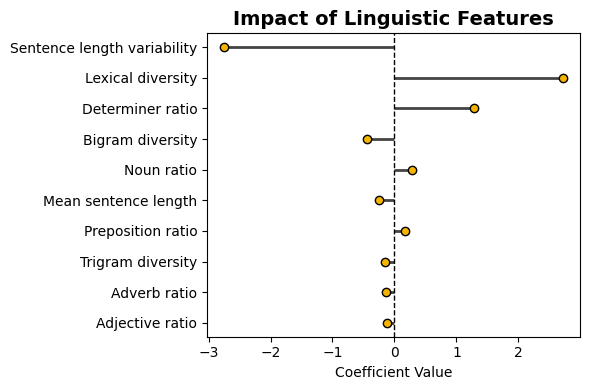

In [28]:
# Display the contribution of linguistic features in the logistic regression model

# Clean labels
feature_names = {
    "noun_ratio": "Noun ratio",
    "det_ratio": "Determiner ratio",
    "adp_ratio": "Preposition ratio",
    "adj_ratio": "Adjective ratio",
    "adv_ratio": "Adverb ratio",
    "lexical_diversity": "Lexical diversity",
    "bigram_div": "Bigram diversity",
    "trigram_div": "Trigram diversity",
    "sentence_length_mean": "Mean sentence length",
    "sentence_length_std": "Sentence length variability"
}

coef = pd.Series(best_model_ling.coef_[0], index=features).sort_values(key=abs)

labels = [feature_names[f] for f in coef.index]
values = coef.values

plt.figure(figsize=(6,4))

# Feature coefficients
plt.hlines(y=labels, xmin=0, xmax=values, color="#444444", linewidth=2)

# Coefficient markers
plt.scatter( values, labels, color="#F4B400", edgecolors="black", zorder=3)

# Reference line
plt.axvline(0, linestyle="--", color="black", linewidth=1)
plt.title("Impact of Linguistic Features", fontsize=14, weight="bold")
plt.xlabel("Coefficient Value")

plt.tight_layout()
plt.show()

### Neural Network

In [29]:
class IAClassification(nn.Module):
    def __init__(self,  input_size, output_size, n_layers, hidden_size, dropout):
        super().__init__()
 
        layers = []
        # Setting up the input layer 
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(p=dropout))

        # Setting up the hidden layers
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout))

        # Setting up the output layer for binary classification
        layers.append(nn.Linear(hidden_size, output_size))
        layers.append(nn.Sigmoid()) 

        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x).squeeze(-1)

In [30]:
def train(X_train, y_train, X_dev, y_dev, X_test, y_test,
          num_epochs, learning_rate, hidden_size, n_layers, dropout):

    print('Initialising model, optimizer, and loss function')
    input_size = X_train.shape[1]
    output_size = 1
    model = IAClassification(input_size, output_size, n_layers, hidden_size, dropout)
    optimizer = optim.Adam(model.parameters(),
                           lr=learning_rate)
    criterion = nn.BCELoss()

    best_dev_acc = 0
    stable_counter = 0
    min_loss = torch.inf

    print('Starting training...')
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    for epoch in range(num_epochs):

        # Train 
        model.train()
        for x_batch, y_batch in loader:
            
            # Forward pass (calls the model's forward func)
            y_hat = model(x_batch)
            # Compute loss
            loss = criterion(y_hat, y_batch.float())

            # Backward pass
            optimizer.zero_grad()  # Clear prev gradients
            loss.backward()  # Compute new gradients
            optimizer.step()  # Update model parameters

        # Dev
        model.eval()
        with torch.no_grad():
            dev_outputs = model(X_dev).squeeze()
            dev_loss = criterion(dev_outputs, y_dev.float())
            dev_preds = (dev_outputs > 0.5).float()
            dev_acc = (
                (dev_preds == y_dev)
                .float()
                .mean()
                .item()
            )

        print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train loss: {loss.item():.4f} | "
        f"Dev acc: {dev_acc:.4f}"
        )

        # Early stopping check 
        if dev_loss < min_loss:
            min_loss = dev_loss
            best_dev_acc = dev_acc
            best_model_state = model.state_dict()
            stable_counter = 0
        
        else : 
            stable_counter += 1
            if stable_counter >= 5:
                print(f"Early stopping at epoch {epoch+1}")
                break


    model.load_state_dict(best_model_state)

    return model, best_dev_acc

In [31]:
# Hyperparameters to test
param_grid = {
    "learning_rate": [1e-3, 5e-4],
    "hidden_size": [64, 128],
    "n_layers": [2, 4],
    "dropout": [0.1, 0.3]
}

best_model = None
best_params = None
best_dev_acc = 0

# Iterate through all hyperparameter combinations
for lr in param_grid["learning_rate"]:
    for hs in param_grid["hidden_size"]:
        for nl in param_grid["n_layers"]:
            for dr in param_grid["dropout"]:

                print("\nTesting configuration:")
                print(
                    f"lr={lr}, "
                    f"hidden={hs}, "
                    f"layers={nl}, "
                    f"dropout={dr}"
                )

                model, dev_acc = train(
                    X_train,
                    y_train,
                    X_dev,
                    y_dev,
                    X_test,
                    y_test,
                    num_epochs=30,
                    learning_rate=lr,
                    hidden_size=hs,
                    n_layers=nl,
                    dropout=dr
                )

                print(f"Dev accuracy: {dev_acc:.4f}")

                # Keep the model with the best dev accuracy
                if dev_acc > best_dev_acc:
                    best_dev_acc = dev_acc
                    best_model = model
                    best_params = {
                        "learning_rate": lr,
                        "hidden_size": hs,
                        "n_layers": nl,
                        "dropout": dr
                    }


Testing configuration:
lr=0.001, hidden=64, layers=2, dropout=0.1
Initialising model, optimizer, and loss function
Starting training...
Epoch 1/30 | Train loss: 0.6892 | Dev acc: 0.7100
Epoch 2/30 | Train loss: 0.6531 | Dev acc: 0.7100
Epoch 3/30 | Train loss: 0.5708 | Dev acc: 0.6800
Epoch 4/30 | Train loss: 0.5828 | Dev acc: 0.7400
Epoch 5/30 | Train loss: 0.3997 | Dev acc: 0.7500
Epoch 6/30 | Train loss: 0.4229 | Dev acc: 0.8200
Epoch 7/30 | Train loss: 0.3804 | Dev acc: 0.8400
Epoch 8/30 | Train loss: 0.2249 | Dev acc: 0.8500
Epoch 9/30 | Train loss: 0.3300 | Dev acc: 0.8500
Epoch 10/30 | Train loss: 0.2328 | Dev acc: 0.8600
Epoch 11/30 | Train loss: 0.2502 | Dev acc: 0.8600
Epoch 12/30 | Train loss: 0.2725 | Dev acc: 0.8500
Epoch 13/30 | Train loss: 0.1767 | Dev acc: 0.8700
Epoch 14/30 | Train loss: 0.3734 | Dev acc: 0.8600
Epoch 15/30 | Train loss: 0.1902 | Dev acc: 0.8800
Epoch 16/30 | Train loss: 0.2959 | Dev acc: 0.8800
Epoch 17/30 | Train loss: 0.0964 | Dev acc: 0.8500
Epoch

In [32]:
with torch.no_grad():
    pred_nn = (
        best_model(X_test).squeeze() > 0.5
    ).int().numpy()

results_nn = evaluate_model(
    best_model,
    X_test,
    y_test
)

print("Best parameters:")
print(best_params)

print("\nTest metrics:")
print(results_nn)

Best parameters:
{'learning_rate': 0.001, 'hidden_size': 128, 'n_layers': 4, 'dropout': 0.1}

Test metrics:
{'Accuracy': 0.96, 'Precision': 0.9259259259259259, 'Recall': 1.0, 'F1-score': 0.9615384615384616}


In [33]:
# Diagnosis of the NN
best_model.eval()

with torch.no_grad():
    y_train_pred = best_model(X_train)

y_train_pred = (y_train_pred > 0.5).int()

acc = accuracy_score(y_train.numpy(), y_train_pred.numpy())
print(f"Train accuracy: {acc:.4f}")

Train accuracy: 0.9550


### NN with linguistic features

In [34]:
# Convert data to PyTorch tensors

X_train_ling = torch.tensor(
    X_train_ling.to_numpy(),
    dtype=torch.float32
)

X_dev_ling = torch.tensor(
    X_dev_ling.to_numpy(),
    dtype=torch.float32
)

X_test_ling = torch.tensor(
    X_test_ling.to_numpy(),
    dtype=torch.float32
)

y_train_ling = torch.tensor(
    y_train_ling.to_numpy(),
    dtype=torch.float32
)

y_dev_ling = torch.tensor(
    y_dev_ling.to_numpy(),
    dtype=torch.float32
)

y_test_ling = torch.tensor(
    y_test_ling.to_numpy(),
    dtype=torch.float32
)

In [35]:
# Hyperparameters to test
param_grid = {
    "learning_rate": [1e-3, 5e-4],
    "hidden_size": [64, 128],
    "n_layers": [2, 4],
    "dropout": [0.1, 0.3]
}

best_model_ling = None
best_params_ling = None
best_dev_acc_ling = 0

# Iterate through all hyperparameter combinations

for lr in param_grid["learning_rate"]:
    for hs in param_grid["hidden_size"]:
        for nl in param_grid["n_layers"]:
            for dr in param_grid["dropout"]:
                print("\nTesting configuration:")

                print(
                    f"lr={lr}, "
                    f"hidden={hs}, "
                    f"layers={nl}, "
                    f"dropout={dr}"
                )

                model_ling, dev_acc_ling = train(
                    X_train_ling,
                    y_train_ling,
                    X_dev_ling,
                    y_dev_ling,
                    X_test_ling,
                    y_test_ling,
                    num_epochs=30,
                    learning_rate=lr,
                    hidden_size=hs,
                    n_layers=nl,
                    dropout=dr
                )

                print(
                    f"Dev accuracy: "
                    f"{dev_acc_ling:.4f}"
                )

                # Keep best model
                if dev_acc_ling > best_dev_acc_ling:
                    best_dev_acc_ling = dev_acc_ling
                    best_model_ling = model_ling
                    best_params_ling = {
                        "learning_rate": lr,
                        "hidden_size": hs,
                        "n_layers": nl,
                        "dropout": dr
                    }


Testing configuration:
lr=0.001, hidden=64, layers=2, dropout=0.1
Initialising model, optimizer, and loss function
Starting training...
Epoch 1/30 | Train loss: 0.4692 | Dev acc: 0.7000
Epoch 2/30 | Train loss: 0.5621 | Dev acc: 0.7800
Epoch 3/30 | Train loss: 0.5031 | Dev acc: 0.7800
Epoch 4/30 | Train loss: 0.3895 | Dev acc: 0.7700
Epoch 5/30 | Train loss: 0.7342 | Dev acc: 0.7800
Epoch 6/30 | Train loss: 0.7702 | Dev acc: 0.7700
Epoch 7/30 | Train loss: 0.4396 | Dev acc: 0.8200
Epoch 8/30 | Train loss: 0.4223 | Dev acc: 0.7600
Epoch 9/30 | Train loss: 0.4506 | Dev acc: 0.7400
Epoch 10/30 | Train loss: 0.3610 | Dev acc: 0.7800
Epoch 11/30 | Train loss: 0.3154 | Dev acc: 0.7700
Epoch 12/30 | Train loss: 0.4803 | Dev acc: 0.7900
Epoch 13/30 | Train loss: 0.3288 | Dev acc: 0.7900
Epoch 14/30 | Train loss: 0.5804 | Dev acc: 0.7800
Epoch 15/30 | Train loss: 0.3931 | Dev acc: 0.7700
Early stopping at epoch 15
Dev accuracy: 0.7800

Testing configuration:
lr=0.001, hidden=64, layers=2, drop

In [36]:
with torch.no_grad():
    pred_nn_ling = (
        best_model_ling(X_test_ling).squeeze() > 0.5
    ).int().numpy()

results_nn_ling = evaluate_model(
    best_model_ling,
    X_test_ling,
    y_test_ling
)

print("Best parameters:")
print(best_params_ling)

print("\nTest metrics:")
print(results_nn_ling)

Best parameters:
{'learning_rate': 0.001, 'hidden_size': 128, 'n_layers': 4, 'dropout': 0.3}

Test metrics:
{'Accuracy': 0.78, 'Precision': 0.7692307692307693, 'Recall': 0.8, 'F1-score': 0.7843137254901961}


In [37]:
# Diagnosis of the NN with linguistic features
best_model_ling.eval()

with torch.no_grad():
    y_train_pred = best_model_ling(X_train_ling)

y_train_pred = (y_train_pred > 0.5).int()

acc = accuracy_score(y_train.numpy(), y_train_pred.numpy())
print(f"Train accuracy: {acc:.4f}")

Train accuracy: 0.8250


### Hugging face AI detector

In [38]:
model_path = "Oxidane/tmr-ai-text-detector"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

The following code was partly provided by the creators of the model and can be found at the following adress : https://huggingface.co/Oxidane/tmr-ai-text-detector

In [39]:
batch_size = 16
pred_hf = []
test_texts = df.iloc[idx_test]["text"].tolist()

for i in range(0, len(test_texts), batch_size):
    batch_texts = test_texts[i:i+batch_size]

    inputs = tokenizer(
        batch_texts,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
    
    # Probability that text is AI-generated
    batch_preds = (probs[:, 1] > 0.5).int().tolist()
    # Binary classification (threshold=0.5)
    pred_hf.extend(batch_preds)

# Compute metrics
accuracy = accuracy_score(y_test.numpy(), pred_hf)
precision = precision_score(y_test.numpy(), pred_hf)
recall = recall_score(y_test.numpy(), pred_hf)
f1 = f1_score(y_test.numpy(), pred_hf)

# Store results
results_hf = {
    "Accuracy": float(accuracy),
    "Precision": float(precision),
    "Recall": float(recall),
    "F1-score": float(f1)
}

print(results_hf)

{'Accuracy': 0.92, 'Precision': 0.9772727272727273, 'Recall': 0.86, 'F1-score': 0.9148936170212766}


## Summary results

In [40]:
# Global comparison table

results_df = pd.DataFrame({
    "LogReg embeddings": results_logreg,
    "LogReg embeddings + linguistic": results_logreg_ling,
    "NN embeddings": results_nn,
    "NN embeddings + linguistic": results_nn_ling,
    "Hugging Face model": results_hf
}).T

# Round values
results_df = results_df.round(4)
print(results_df)

                                Accuracy  Precision  Recall  F1-score
LogReg embeddings                   0.94     0.9400    0.94    0.9400
LogReg embeddings + linguistic      0.94     0.9231    0.96    0.9412
NN embeddings                       0.96     0.9259    1.00    0.9615
NN embeddings + linguistic          0.78     0.7692    0.80    0.7843
Hugging Face model                  0.92     0.9773    0.86    0.9149


## Test significance

In [41]:
def mcnemar_test(y_true, pred1, pred2):

    # Correct predictions
    pred1_correct = (pred1 == y_true)
    pred2_correct = (pred2 == y_true)

    # Contingency table
    both_correct = (
        (pred1_correct == 1) &
        (pred2_correct == 1)
    ).sum()

    pred1_only = (
        (pred1_correct == 1) &
        (pred2_correct == 0)
    ).sum()

    pred2_only = (
        (pred1_correct == 0) &
        (pred2_correct == 1)
    ).sum()

    both_wrong = (
        (pred1_correct == 0) &
        (pred2_correct == 0)
    ).sum()

    table = [
        [both_correct, pred1_only],
        [pred2_only, both_wrong]
    ]

    # McNemar test
    result = mcnemar(
        table,
        exact=False,
        correction=True
    )

    return {
        "Statistic": float(result.statistic),
        "p-value": float(result.pvalue)
    }

In [42]:
y_true = y_test.numpy()

mcnemar_nn = mcnemar_test(
    y_true,
    pred_nn,
    pred_nn_ling
)
print("NN vs NN + linguistic")
print(mcnemar_nn)


mcnemar_logreg = mcnemar_test(
    y_true,
    pred_logreg,
    pred_logreg_ling
)
print("LogReg vs LogReg + linguistic")
print(mcnemar_logreg)

mcnemar_hf = mcnemar_test(
    y_true,
    pred_hf,
    pred_nn_ling
)
print("HF vs NN + linguistic")
print(mcnemar_hf)

mcnemar_hf_2 = mcnemar_test(
    y_true,
    pred_hf,
    pred_nn
)
print("HF vs NN")
print(mcnemar_hf_2)

NN vs NN + linguistic
{'Statistic': 12.041666666666666, 'p-value': 0.0005202443475902309}
LogReg vs LogReg + linguistic
{'Statistic': 0.08333333333333333, 'p-value': 0.7728299926844475}
HF vs NN + linguistic
{'Statistic': 6.5, 'p-value': 0.010787449254670376}
HF vs NN
{'Statistic': 0.75, 'p-value': 0.3864762307712325}


## Visualisations

### POS distrubition

In [43]:
# Plotting style
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10
})

df_ai = df[df["label"] == 1]
df_human = df[df["label"] == 0]

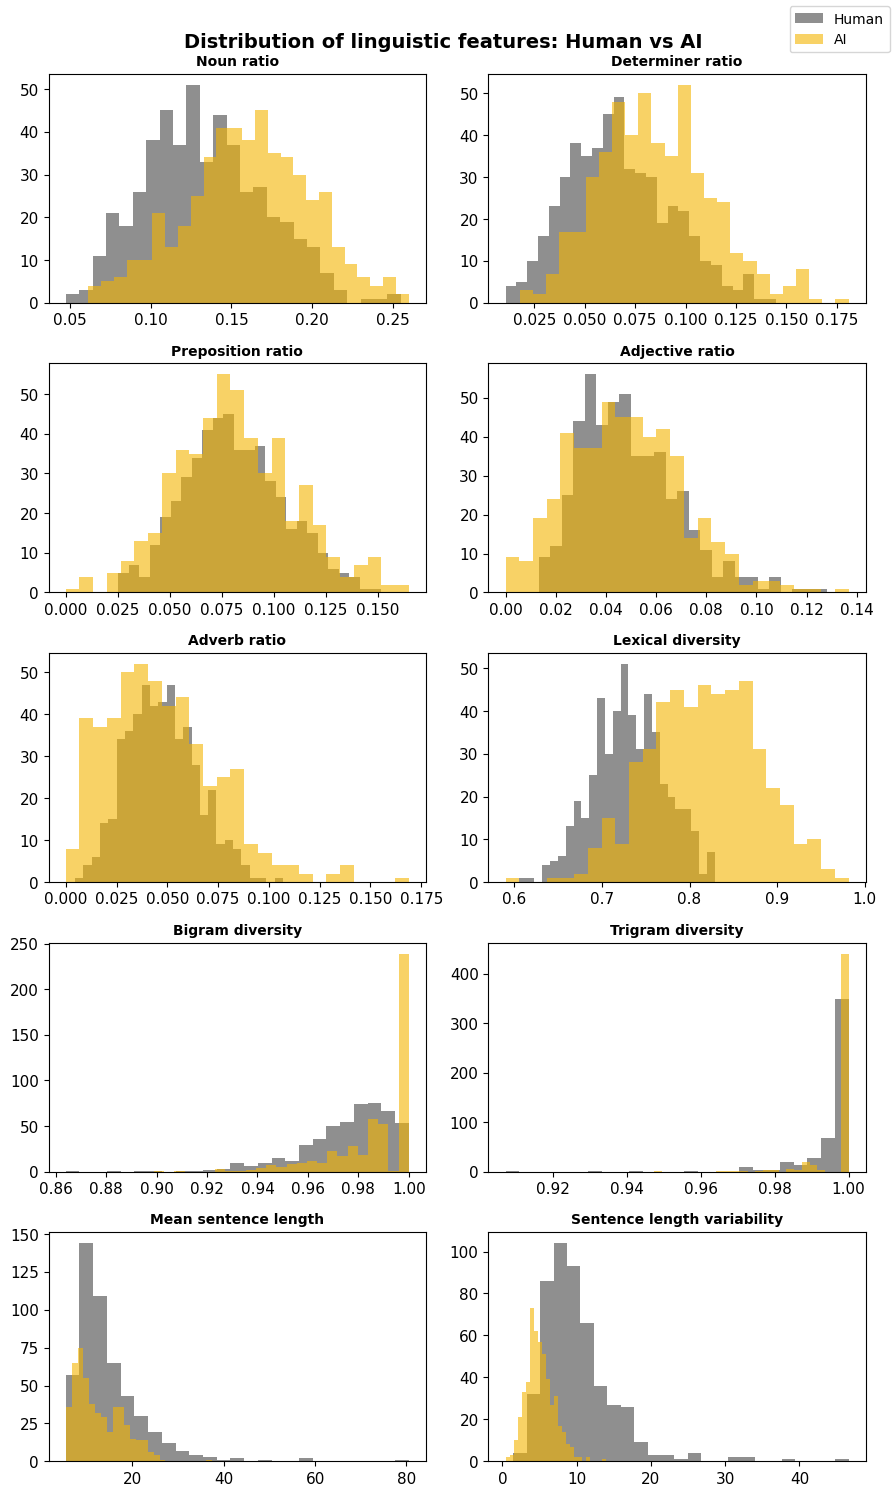

In [52]:
# Compare the distribution of linguistic features for human and AI-generated texts
fig, axes = plt.subplots(5, 2, figsize=(9, 15))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    # Human texts
    ax.hist(
        df_human[feature],
        bins=25,
        alpha=0.6,
        color="#444444",
        label="Human"
    )

    # AI-generated texts
    ax.hist(
        df_ai[feature],
        bins=25,
        alpha=0.6,
        color="#F4B400",
        label="AI"
    )

    ax.set_title(feature_names[feature], fontsize=10, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.suptitle("Distribution of linguistic features: Human vs AI", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()